---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** ______________ &nbsp; **학번:** ______________ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

1. Loading raw dataset...


   Raw dataset shape: (16721, 23)
2. Filtering for single 'Chemical' records and valid SMILES...
   Filtered dataset shape: (11948, 23)
3. Target filtering: Endpoint == 'LD50' and defining Toxicity Label...
   LD50 dataset shape: (11948, 24)
   Label counts:
label
0    8243
1    3705
Name: count, dtype: int64
4. Purifying SMILES (removing dots, removing salts)...


   After SMILES purification & deduplication shape: (7279, 25)
5. Calculating 2D Descriptors & Morgan Fingerprints...


   Final dataset shape: (7279, 1225)
6. Plotting and saving visualizations...


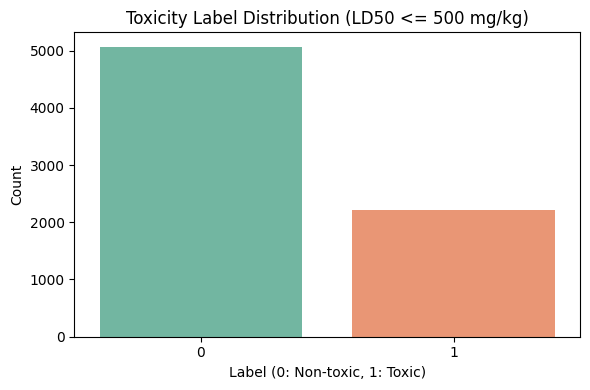

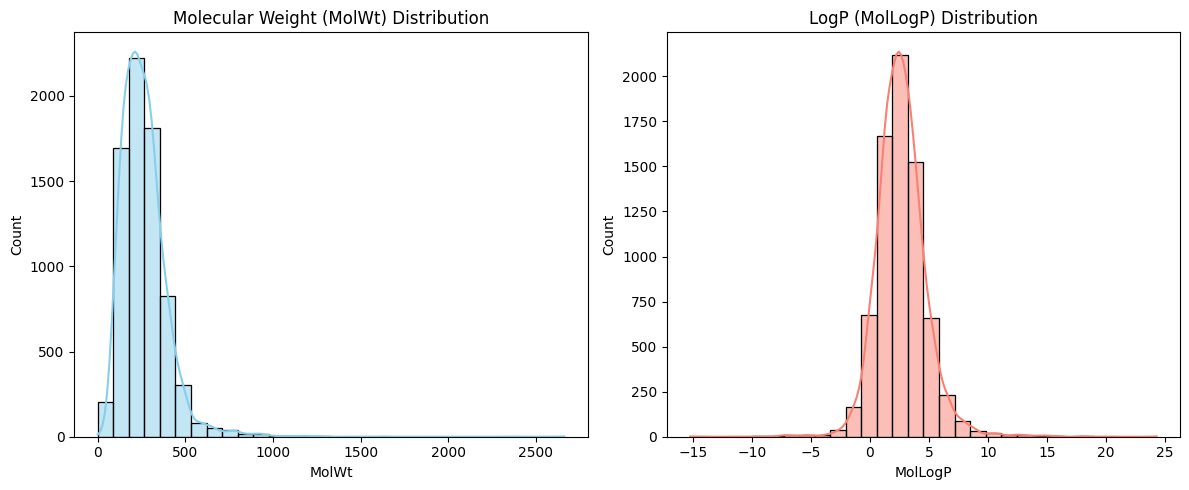

7. Exporting to final_dataset_descriptors.csv...


   Exported successfully. Finished!


In [1]:
# 1. 라이브러리 임포트 및 경고 억제
import warnings
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import AllChem

# 2. 데이터셋 불러오기
print("1. Loading raw dataset...")
raw_df = pd.read_excel('acute_oral.xlsx', sheet_name='Data')
print(f"   Raw dataset shape: {raw_df.shape}")

# 3. 화학물질 선별 및 유효 SMILES 확인
print("2. Filtering for single 'Chemical' records and valid SMILES...")
df = raw_df[raw_df['Mixture'] == 'Chemical'].copy()
df = df.dropna(subset=['SMILES'])
print(f"   Filtered dataset shape: {df.shape}")

# 4. 이진 독성 라벨(Toxicity Label) 생성 (LD50 <= 500 mg/kg -> 1, 그 외 -> 0)
print("3. Target filtering: Endpoint == 'LD50' and defining Toxicity Label...")
df_ld50 = df[df['Endpoint'] == 'LD50'].copy()
df_ld50['Response'] = pd.to_numeric(df_ld50['Response'], errors='coerce')
df_ld50 = df_ld50.dropna(subset=['Response'])
df_ld50['label'] = (df_ld50['Response'] <= 500).astype(int)
print(f"   LD50 dataset shape: {df_ld50.shape}")
print(f"   Label counts:\n{df_ld50['label'].value_counts()}")

# 5. SMILES 정제 (중복 구조 및 염 제거)
print("4. Purifying SMILES (removing dots, removing salts)...")
df_ld50 = df_ld50[~df_ld50['SMILES'].str.contains(r'\.', regex=True)]

remover = SaltRemover()
def clean_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        stripped_mol = remover.StripMol(mol)
        stripped_smi = Chem.MolToSmiles(stripped_mol)
        
        parts = stripped_smi.split('.')
        active_part = max(parts, key=len)
        return active_part
    except:
        return None

df_ld50['smi_clean'] = df_ld50['SMILES'].apply(clean_smiles)
df_ld50 = df_ld50.dropna(subset=['smi_clean'])
df_ld50 = df_ld50.drop_duplicates(subset=['smi_clean'])
print(f"   After SMILES purification & deduplication shape: {df_ld50.shape}")

# 6. RDKit Descriptor 및 Morgan Fingerprint 피처 계산
print("5. Calculating 2D Descriptors & Morgan Fingerprints...")
def get_descriptors(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        return Descriptors.CalcMolDescriptors(mol)
    except:
        return None

df_ld50['descriptors'] = df_ld50['smi_clean'].apply(get_descriptors)
df_ld50 = df_ld50.dropna(subset=['descriptors'])
desc_df = pd.DataFrame(df_ld50['descriptors'].tolist(), index=df_ld50.index)

def get_fingerprint(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        return np.array(fp)
    except:
        return None

df_ld50['fingerprints'] = df_ld50['smi_clean'].apply(get_fingerprint)
df_ld50 = df_ld50.dropna(subset=['fingerprints'])
fp_cols = [f'FP_{i}' for i in range(1024)]
fp_df = pd.DataFrame(df_ld50['fingerprints'].tolist(), columns=fp_cols, index=df_ld50.index)

final_df = pd.concat([
    df_ld50[['Chemical_Name', 'smi_clean', 'label']].rename(columns={'smi_clean': 'SMILES'}),
    desc_df,
    fp_df
], axis=1)
final_df = final_df.dropna(axis=1)
print(f"   Final dataset shape: {final_df.shape}")

# 7. 데이터 및 라벨 현황 시각화
print("6. Plotting and saving visualizations...")
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=final_df, hue='label', legend=False, palette='Set2')
plt.title('Toxicity Label Distribution (LD50 <= 500 mg/kg)')
plt.xlabel('Label (0: Non-toxic, 1: Toxic)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(final_df['MolWt'], kde=True, bins=30, color='skyblue')
plt.title('Molecular Weight (MolWt) Distribution')
plt.xlabel('MolWt')

plt.subplot(1, 2, 2)
sns.histplot(final_df['MolLogP'], kde=True, bins=30, color='salmon')
plt.title('LogP (MolLogP) Distribution')
plt.xlabel('MolLogP')
plt.tight_layout()
plt.savefig('molecular_properties_distribution.png', dpi=150)
plt.show()

# 8. 최종 데이터셋 저장
print("7. Exporting to final_dataset_descriptors.csv...")
final_df.to_csv('final_dataset_descriptors.csv', index=False)
print("   Exported successfully. Finished!")
